In [1]:
import pyarrow.parquet as pq

In [19]:
parquet_file = pq.ParquetFile('/data/input/Files/yangjian_lab_result/gsMap/human_fetal_brain_bin100/obs_ldsc_merged_obs_4_traits_24.parquet')
table = parquet_file.read().to_pandas()

names = [
 '14_A03591A1C3_WT202403310045.h5ad',
 '16_A03592A4C6_WT202403310044.h5ad',
 '18_B03602C4D6_WT202405020031.h5ad',
 '20_B03606F3G5_WT202405020032.h5ad',
 '22_B03606C4E6_WT202403310050.h5ad',
 '23_B03609A4D6_WT202404150263.h5ad',
 '27_B03610C1E3_WT202403310051.h5ad',
 '31_B03619A1D3_WT202403310052.h5ad',
 '35_B03619E4G6_WT202403310053.h5ad',
 '39_A03589A1D4_WT202403310046.h5ad',
 '43_A03590E1G4_WT202403310064.h5ad',
 '47_A03593C1F3_WT202403310068.h5ad',
 '51_B03605C2E5_WT202406020126.h5ad',
 '55_B03613E3G6_WT202403310069.h5ad',
 '59_B03612E4G6_WT202403310059.h5ad',
 '63_B03606C1E3_WT202403310061.h5ad',
 '67_A03595A1D3_WT202403310062.h5ad',
 '71_A03595A4D6_WT202403310063.h5ad',
 '75_D03468D1E3_WT202403310066.h5ad',
 '80_D03473D4E6_WT202403310070.h5ad',
 '84_B03423D1E3_WT202403310065.h5ad',
 '89_D03466A1C3_WT202403310058.h5ad',
 '99_D03470D1E3_WT202404290071.h5ad',
 '104_B03615F3G5_WT202405020035.h5ad',
 '105_D03468A4C6_WT202403310067.h5ad',
]
sample_name = [i.replace('.h5ad', '') for i in names]
print(len(table))
table = table[table['sample_name'].isin(sample_name)]

4820236


In [20]:
len(table)

3427491

In [21]:
import scanpy as sc
import anndata as ad
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import ListedColormap, rgb2hex
import numpy as np
import warnings
import pandas as pd
warnings.filterwarnings('ignore')
import numpy as np
from sklearn.metrics import jaccard_score
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42 # ADOBE AI 字帖
from matplotlib.font_manager import fontManager, FontProperties

fontManager.addfont('/data/work/Arial.ttf')

font = FontProperties(fname='/data/work/Arial.ttf')
font_name = font.get_name()
plt.rcParams['font.family'] = font_name
adata = sc.read_h5ad('/data/work/05.cluster/FuseMap/0106/thalamus_latent_embeddings_all_spatial_pretrain/dmt_leiden_20250108_1.h5ad')
adata

AnnData object with n_obs × n_vars = 3279854 × 33347
    obs: 'dnbCount', 'area', 'orig.ident', 'x', 'y', 'region', 'n_counts', 'region_h2', 'slice_code', 'sub_region', 'dmt_leiden', 'annotation_1230', 'dmt_leiden_merge'
    uns: 'dmt_leiden_colors', 'dmt_leiden_merge_colors', 'dmt_nn', 'leiden', 'slice_code_colors'
    obsm: 'X_dmt', 'X_dmt_highdim', 'align_spatial_2d', 'align_spatial_3d', 'cell_border', 'latent_embeddings_all_single_pretrain', 'latent_embeddings_all_spatial_pretrain', 'spatial', 'spatial_division'
    obsp: 'dmt_nn_connectivities', 'dmt_nn_distances'

In [22]:
adata.obs_names_make_unique()

In [41]:
from scipy.spatial import KDTree

def bin100_2_bin50(adata_bin50, adata_bin100, bin100_anno, bin50_anno):
    unique_celltypes = adata_bin100.obs[bin100_anno].unique()
    dic = pd.Series(index=unique_celltypes, data=range(1, len(unique_celltypes) + 1))
    celltype_ids = adata_bin100.obs[bin100_anno].map(dic).fillna(0).astype(int)
    bin100_coords = np.column_stack((adata_bin100.obs['x'], adata_bin100.obs['y']))
    tree = KDTree(bin100_coords)
    bin50_coords = adata_bin50.obsm['spatial']
    _, nearest_indices = tree.query(bin50_coords)
    bin50_region_type_ids = celltype_ids.iloc[nearest_indices].values
    dic_reverse = {v: k for k, v in dic.items()}
    dic_reverse[0] = 'others'
    adata_bin50.obs[bin50_anno] = [dic_reverse[i] for i in bin50_region_type_ids]
    return adata_bin50

In [36]:
diseases = ['Standard error of hit reaction time', 'TS', 'Alertiing', 'PD', 'ADHD',
       'PTSD', 'SCZ', 'Cognitive performance', 'IQ', 'SESA', 'Orienting',
       'Depression', 'Insomnia', 'Stroke', 'Hit reaction time', 'Epilepsy',
       'Bipolar', 'ASD', 'Neuroticism', 'AD', 'GGE', 'Excutive function',
       'ALS', 'MDD']

In [45]:
adatas = []
for name in names:
    sample_name = name.replace('.h5ad', '')
    adata_bin100 = sc.read_h5ad(f'/data/work/05.cluster/FuseMap/1130/datas/whole_brain_bin100/{name}')
    adata_cellbin = adata[adata.obs['slice_code'] == name]
    table_bin100 = table[table['sample_name'] == sample_name]
    table_bin100.index = [i.replace('_'+sample_name, '') for i in table_bin100.index]
    inter = list(set(adata_bin100.obs.index.tolist()) & set(table_bin100.index.tolist()))
    adata_bin100 = adata_bin100[inter].copy()
    table_bin100 = table_bin100.loc[adata_bin100.obs.index]
    for disease in diseases:
        adata_bin100.obs[disease] = table_bin100[disease].tolist()
        adata_cellbin = bin100_2_bin50(adata_cellbin, adata_bin100, disease, disease)
    adatas.append(adata_cellbin)

In [ ]:
import anndata as ad

In [ ]:
adata = ad.concat(adatas)
adata

AnnData object with n_obs × n_vars = 2638464 × 33347
    obs: 'dnbCount', 'area', 'orig.ident', 'x', 'y', 'region', 'n_counts', 'region_h2', 'slice_code', 'sub_region', 'dmt_leiden', 'annotation_1230', 'dmt_leiden_merge', 'Standard error of hit reaction time', 'TS', 'Alertiing', 'PD', 'ADHD', 'PTSD', 'SCZ', 'Cognitive performance', 'IQ', 'SESA', 'Orienting', 'Depression', 'Insomnia', 'Stroke', 'Hit reaction time', 'Epilepsy', 'Bipolar', 'ASD', 'Neuroticism', 'AD', 'GGE', 'Excutive function', 'ALS', 'MDD'
    obsm: 'X_dmt', 'X_dmt_highdim', 'align_spatial_2d', 'align_spatial_3d', 'cell_border', 'latent_embeddings_all_single_pretrain', 'latent_embeddings_all_spatial_pretrain', 'spatial', 'spatial_division'

In [ ]:
adata.write('trait.h5ad')

In [50]:
1

1

In [52]:
adata_disease_new = ad.AnnData(adata.obs[diseases].values)
dic = {'0': 'T7_SST_LHX_SIX3',
 '1': 'T9_CRH',
 '10': 'T6_CLSTN2',
 '11': 'T4_COL4A1_vessel',
 '12': 'T3_BMP4_IGFBP5',
 '13': 'T7_SST_LHX_SIX3',
 '14': 'T0_PCP4_VGF',
 '15': 'T9_CRH',
 '16': 'T3_BMP4_IGFBP5',
 '17': 'T3_BMP4_IGFBP5',
 '18': 'T2_PRSS12',
 '19': 'T9_CRH',
 '2': 'T9_CRH',
 '20': 'T1_NTS_CALB1',
 '21': 'T1_NTS_CALB1',
 '22': 'T1_NTS_CALB1',
 '23': 'T10_HBZ',
 '24': 'T1_NTS_CALB1',
 '25': 'T1_NTS_CALB1',
 '26': 'T2_PRSS12',
 '27': 'T9_CRH',
 '28': 'T2_PRSS12',
 '29': 'T5_AQP4_gial_region',
 '3': 'T10_HBZ',
 '30': 'T8_CBLN4_CBLN1',
 '31': 'T7_SST_LHX_SIX3',
 '32': 'T9_CRH',
 '33': 'T1_NTS_CALB1',
 '34': 'T7_SST_LHX_SIX3',
 '35': 'T10_HBZ',
 '36': 'T8_CBLN4_CBLN1',
 '37': 'T9_CRH',
 '38': 'T3_BMP4_IGFBP5',
 '39': 'T1_NTS_CALB1',
 '4': 'T2_PRSS12',
 '40': 'T9_CRH',
 '41': 'T6_CLSTN2',
 '42': 'T10_HBZ',
 '5': 'T7_SST_LHX_SIX3',
 '6': 'T7_SST_LHX_SIX3',
 '7': 'T9_CRH',
 '8': 'T2_PRSS12',
 '9': 'T1_NTS_CALB1'}

adata.obs['dmt_leiden_annotation_0115'] = [dic[i] for i in adata.obs['dmt_leiden']]
adata_disease_new.obs = adata.obs[['dnbCount', 'area', 'orig.ident', 'x', 'y', 'region', 'n_counts', 'region_h2', 'slice_code', 'sub_region', 'dmt_leiden', 'annotation_1230', 'dmt_leiden_merge', 'dmt_leiden_annotation_0115']]
adata_disease_new

AnnData object with n_obs × n_vars = 2638464 × 24
    obs: 'dnbCount', 'area', 'orig.ident', 'x', 'y', 'region', 'n_counts', 'region_h2', 'slice_code', 'sub_region', 'dmt_leiden', 'annotation_1230', 'dmt_leiden_merge', 'dmt_leiden_annotation_0115'

In [53]:
adata_disease_new.var.index = diseases

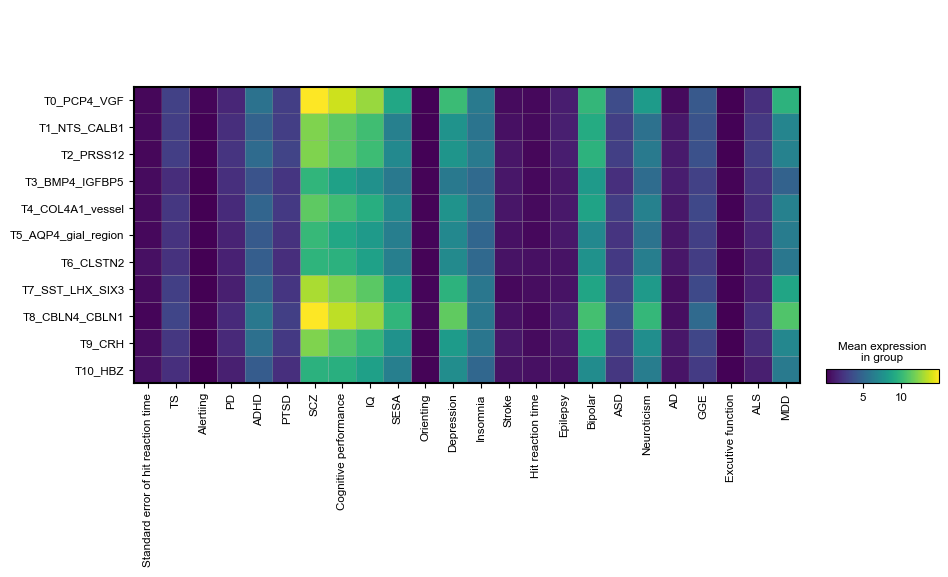

In [54]:
sc.pl.matrixplot(adata_disease_new, 
                 diseases, 'dmt_leiden_annotation_0115',
                 # standard_scale = 'var',
                 #dendrogram = True,
                 # show = False, 
                 var_group_rotation = 45,
                )